In [5]:
import torch
from transformers import PegasusForConditionalGeneration, PegasusTokenizer
import ast
import os
import json
from tqdm import tqdm

# --- 1. SETUP MODEL (From your code) ---
model_name = 'tuner007/pegasus_paraphrase'
torch_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading model {model_name} onto {torch_device}...")
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name).to(torch_device)
print("Model loaded.")

# --- 2. PEGASUS PARAPHRASING FUNCTION (From your code) ---
def get_paraphrases(sentence, num_return_sequences=10):
    """Generates multiple paraphrases for a base sentence."""
    batch = tokenizer(
        [sentence], truncation=True, padding='longest', max_length=60, return_tensors="pt"
    ).to(torch_device)
    
    translated = model.generate(
        **batch,
        max_length=60,
        num_beams=10,
        num_return_sequences=num_return_sequences,
        temperature=1.5
    )
    
    tgt_text = tokenizer.batch_decode(translated, skip_special_tokens=True)
    return tgt_text

# --- 3. METADATA PARSING & PARAPHRASING (UPDATED FOR TOP 3) ---
def generate_paraphrase_cache(metadata_file):
    """
    Reads the metadata.txt file, finds unique TOP 3 landcover combinations,
    and generates paraphrases for each.
    """
    
    print(f"Reading metadata from {metadata_file}...")
    unique_combinations = set()
    
    # --- First pass: Find all unique TOP 3 combinations ---
    with open(metadata_file, 'r') as f:
        for line in f:
            try:
                parts = line.strip().split(None, 1)
                if len(parts) < 2: continue
                
                metadata = ast.literal_eval(parts[1])
                landcover = metadata.get('landcover_distribution', {})
                if not landcover: continue

                top_covers = sorted(landcover.items(), key=lambda item: item[1], reverse=True)
                
                # --- !!! THIS IS THE MODIFIED LOGIC !!! ---
                # Extract top 3, using "None" as a default/placeholder
                cover_1 = top_covers[0][0] if len(top_covers) >= 1 else "None"
                cover_2 = top_covers[1][0] if len(top_covers) >= 2 else "None"
                cover_3 = top_covers[2][0] if len(top_covers) >= 3 else "None"
                
                # Create the new unique key
                key = f"{cover_1}_{cover_2}_{cover_3}"
                
                # Add the tuple with all 3 covers to the set
                if cover_1 != "None":
                    unique_combinations.add((key, cover_1, cover_2, cover_3))
                # --- !!! END OF MODIFIED LOGIC !!! ---

            except Exception as e:
                print(f"Skipping line on error: {e}")

    print(f"Found {len(unique_combinations)} unique landcover combinations.")

    # --- Second pass: Generate paraphrases for each unique combo ---
    paraphrase_cache = {}
    
    # Use tqdm for a progress bar
    # --- !!! THIS LOOP IS ALSO MODIFIED !!! ---
    for key, cover_1, cover_2, cover_3 in tqdm(unique_combinations, desc="Generating Paraphrases"):
        
        # Create a dynamic, informative base sentence
        if cover_3 != "None":
            base_sentence = f"A satellite image showing a mix of {cover_1}, {cover_2}, and {cover_3}."
        elif cover_2 != "None":
            base_sentence = f"A satellite image showing a mix of {cover_1} and {cover_2}."
        else: # Only cover_1 exists
            base_sentence = f"A satellite image of an area that is mostly {cover_1}."
        # --- !!! END OF MODIFIED LOGIC !!! ---

        # Generate 10 paraphrases for this one sentence
        try:
            paraphrases = get_paraphrases(base_sentence, num_return_sequences=10)
            # Add the original base sentence to the list for more variety
            paraphrases.append(base_sentence)
            paraphrase_cache[key] = paraphrases
        except Exception as e:
            print(f"Failed to generate for {key}: {e}")
            
    return paraphrase_cache

# --- 4. RUN THE SCRIPT ---
if __name__ == "__main__":
    
    METADATA_FILE = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"
    # --- !! IMPORTANT: Use a new cache file name !! ---
    CACHE_FILE = "paraphrase_cache_top3.json" 

    # Run the main generation function
    generated_cache = generate_paraphrase_cache(METADATA_FILE)

    # Save the results to a file
    with open(CACHE_FILE, 'w') as f:
        json.dump(generated_cache, f, indent=2)

    print(f"\n--- Successfully generated and saved top-3 cache to {CACHE_FILE} ---")
    
    # --- EXAMPLE OF IT (as you asked) ---
    print("\n--- EXAMPLE OUTPUTS FROM THE CACHE ---")
    
    # Show 3 examples from the cache
    for i, (key, phrases) in enumerate(generated_cache.items()):
        if i >= 3:
            break
        print(f"\nLandcover Key: '{key}'")
        print("Generated Paraphrases:")
        for j, phrase in enumerate(phrases[:5]): # Show first 5 phrases
            print(f"  {j+1}: {phrase}")

Loading model tuner007/pegasus_paraphrase onto cuda...


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at tuner007/pegasus_paraphrase and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded.
Reading metadata from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt...
Skipping line on error: malformed node or string on line 1: <ast.Name object at 0x7fbe9ce8bc50>
Found 64 unique landcover combinations.


Generating Paraphrases: 100%|██████████| 64/64 [00:20<00:00,  3.14it/s]


--- Successfully generated and saved top-3 cache to paraphrase_cache_top3.json ---

--- EXAMPLE OUTPUTS FROM THE CACHE ---

Landcover Key: 'Cropland_None_None'
Generated Paraphrases:
  1: The area is mostly Cropland.
  2: An area that is mostly Cropland is shown in a satellite image.
  3: An area that is mostly Cropland has a satellite image.
  4: An area that is mostly Cropland is depicted in a satellite image.
  5: There is a satellite image of Cropland.

Landcover Key: 'Cropland_Built-up_Tree cover'
Generated Paraphrases:
  1: A mix of Cropland, Built-up, and Tree cover is shown in a satellite image.
  2: Cropland, Built-up, and Tree cover are shown in a satellite image.
  3: Cropland, built-up, and tree cover are shown in a satellite image.
  4: A mix of Cropland, Built-up, and Tree cover can be seen in a satellite image.
  5: A mix of Cropland, Built-up and Tree cover is shown in a satellite image.

Landcover Key: 'Built-up_Grassland_Cropland'
Generated Paraphrases:
  1: A mix of

In [ ]:
# Contrastive learning between satellite images and metadata captions
# Image encoder: DINOv3 ViT L 16 (CLS token) fine tuned end to end
# Text encoder: SentenceTransformer (all-mpnet-base-v2) with projection head
# Saves DINO backbone every 5 epochs and plots loss, accuracy, and text similarity

import os, ast, json, math, random, re
from typing import Dict, Any, List, Tuple, Optional
from PIL import Image
import matplotlib.pyplot as plt
import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel

# =========================
# config
# =========================
SEED = 42
EPOCHS = 50
BATCH_SIZE = 16
IMG_SIZE = 800
NUM_WORKERS = 8
MODEL_NAME = "dinov3_vitl16"
DINO_WEIGHTS = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
SAVE_DIR = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/cvpr"
os.makedirs(SAVE_DIR, exist_ok=True)

# learning rates
BACKBONE_LR = 1e-5
HEAD_LR = 5e-4
WEIGHT_DECAY_BACKBONE = 0.05
WEIGHT_DECAY_HEAD = 1e-4

DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda:1"

# =========================
# paths
# =========================
IMAGE_META_SPECS = [
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_val_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_val_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/bangladesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/bangladesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_val_metadata.txt"),
]

# =========================
# caption builder
# =========================
def meta_to_caption(meta: Dict[str, Any]) -> str:
    country = meta.get("country", "Unknown")
    region  = meta.get("region", "Unknown")
    lat = meta.get("lat", None)
    lon = meta.get("lon", None)
    lcd = meta.get("landcover_distribution", {})

    sorted_lc = sorted(lcd.items(), key=lambda kv: kv[1], reverse=True)
    top3 = sorted_lc[:3]
    others = sorted_lc[3:]

    top_str = ", ".join([f"{k} {v:.1f}" for k, v in top3]) if top3 else "no landcover stats"
    others_str = ", ".join([f"{k} {v:.1f}" for k, v in others])

    caption = f"This image contains satellite view "
    caption += f". mainly land cover: {top_str}"
    if others_str:
        caption += f"; minor land cover: {others_str}"
    caption += "."
    return caption

# =========================
# metadata loading
# =========================
def _parse_meta(meta_str: str) -> Optional[Dict[str, Any]]:
    try:
        return ast.literal_eval(meta_str)
    except Exception:
        pass
    try:
        meta_jsonish = re.sub(r"(?<!\\)'", '"', meta_str)
        return json.loads(meta_jsonish)
    except Exception:
        return None

def load_meta_tsv(path: str) -> Dict[str, Dict[str, Any]]:
    mp = {}
    bad = 0
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                bad += 1
                continue
            
            # --- MODIFICATION: Handle both tab and space separation ---
            if "\t" in line:
                parts = line.split("\t", 1)
            else:
                parts = line.split(None, 1) # Splits on any whitespace, max 1 split
            
            if len(parts) != 2:
                bad += 1
                continue
            
            fname, meta_str = parts
            # --- END MODIFICATION ---
            
            meta = _parse_meta(meta_str)
            if isinstance(meta, dict):
                mp[fname] = meta
            else:
                bad += 1
    if bad:
        print(f"Skipped malformed lines: {bad}")
    return mp

def merge_meta_maps(specs: List[Tuple[str,str]]) -> Tuple[List[Tuple[str,str]], Dict[str,Dict[str,Any]]]:
    pairs = []
    global_meta = {}
    for img_dir, meta_path in specs:
        if not os.path.isdir(img_dir) or not os.path.isfile(meta_path):
            print(f"Warning: Skipping invalid path pair: {img_dir} or {meta_path}")
            continue
        meta_map = load_meta_tsv(meta_path)
        print(f"Loaded {len(meta_map)} entries from {meta_path}")
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if fname in meta_map:
                pairs.append((img_dir, fname))
                global_meta[fname] = meta_map[fname]
    print(f"Total merged pairs: {len(pairs)}")
    return pairs, global_meta

# =========================
# dataset
# =========================
IMAGENET_MEAN = [0.430, 0.411, 0.296]
IMAGENET_STD  = [0.213, 0.156, 0.143]

class RSCaptionDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str,str]], meta_map: Dict[str,Dict[str,Any]], size=IMG_SIZE):
        self.pairs = pairs
        self.meta_map = meta_map
        self.tf = T.Compose([
            T.Resize(size),
            T.CenterCrop(size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self): 
        return len(self.pairs)

    def __getitem__(self, idx):
        img_dir, fname = self.pairs[idx]
        path = os.path.join(img_dir, fname)
        img = Image.open(path).convert("RGB")
        x = self.tf(img)
        cap = meta_to_caption(self.meta_map[fname])
        return {"image": x, "caption": cap, "fname": fname}

def build_loader(batch_size=BATCH_SIZE, size=IMG_SIZE, num_workers=NUM_WORKERS):
    pairs, meta_map = merge_meta_maps(IMAGE_META_SPECS)
    ds = RSCaptionDataset(pairs, meta_map, size=size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    return loader

# =========================
# encoders
# =========================
def get_dino_cls(model, images: torch.Tensor) -> torch.Tensor:
    out = model.get_intermediate_layers(images, n=1, return_class_token=True)
    cls = out[-1][1]
    return cls

class DINOImageEncoder(nn.Module):
    def __init__(self, model, proj_dim=512, feat_dim=1024):
        super().__init__()
        self.backbone = model
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, images):
        cls = get_dino_cls(self.backbone, images)
        z = self.head(cls)
        return F.normalize(z, dim=-1)

class HFTextEncoder(nn.Module):
    def __init__(self, name="roberta-base", proj_dim=512, out_dim=768):
        super().__init__()
        print(f"Initializing text encoder with {name}")
        self.tok = AutoTokenizer.from_pretrained(name)
        self.lm  = AutoModel.from_pretrained(name)
        self.proj = nn.Linear(out_dim, proj_dim)

    @torch.no_grad()
    def tokenize(self, texts: List[str], max_len=64, device="cpu"):
        enc = self.tok(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        return {k: v.to(device) for k, v in enc.items()}

    def forward(self, input_ids, attention_mask):
        out = self.lm(input_ids=input_ids, attention_mask=attention_mask)
        last = out.last_hidden_state
        # This is the correct way to do mean pooling
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        z = self.proj(pooled)
        return F.normalize(z, dim=-1)

# =========================
# loss
# =========================
class ClipLoss(nn.Module):
    def __init__(self, init_logit_scale=math.log(1/0.07)):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.tensor(init_logit_scale))

    def forward(self, z_img, z_txt):
        scale = self.logit_scale.exp().clamp(max=100)
        logits_i2t = scale * (z_img @ z_txt.t())
        logits_t2i = logits_i2t.t()
        targets = torch.arange(z_img.size(0), device=z_img.device)
        li2t = F.cross_entropy(logits_i2t, targets)
        lt2i = F.cross_entropy(logits_t2i, targets)
        return 0.5 * (li2t + lt2i), logits_i2t

# =========================
# wrapper
# =========================
class RSCLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder):
        super().__init__()
        self.image_enc = image_encoder
        self.text_enc  = text_encoder
        self.criterion = ClipLoss()

    def forward(self, images, input_ids, attention_mask):
        zi = self.image_enc(images)
        zt = self.text_enc(input_ids, attention_mask)
        loss, logits = self.criterion(zi, zt)
        return loss, logits, zi, zt

# =========================
# dino loader and optimizer
# =========================
def load_dino_vitl16(weights_path: str):
    model = torch.hub.load('facebookresearch/dinov3:main', MODEL_NAME, pretrained=False)
    print(f"Loading DINOv3 weights from: {weights_path}")
    ckpt = torch.load(weights_path, map_location="cpu")
    state = ckpt.get("state_dict", ckpt.get("model", ckpt))
    new_state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(new_state, strict=False)
    return model

def add_param_group(groups, module, lr, wd):
    decay, no_decay = [], []
    for n, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if n.endswith(".bias") or "norm" in n or "ln" in n or "bias" in n:
            no_decay.append(p)
        else:
            decay.append(p)
    if decay:
        groups.append({"params": decay, "lr": lr, "weight_decay": wd})
    if no_decay:
        groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})

def build_optimizer(model, dino_backbone, txt_enc):
    groups = []
    add_param_group(groups, model.image_enc.head, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, txt_enc, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, model.criterion, HEAD_LR, 0.0)
    for p in dino_backbone.parameters():
        p.requires_grad = True
    add_param_group(groups, dino_backbone, BACKBONE_LR, WEIGHT_DECAY_BACKBONE)
    opt = torch.optim.AdamW(groups)
    return opt

# =========================
# training
# =========================
def set_seed(s):
    random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def train():
    set_seed(SEED)

    loader = build_loader(BATCH_SIZE, IMG_SIZE, NUM_WORKERS)

    dino = load_dino_vitl16(DINO_WEIGHTS).to(DEVICE)
    img_enc = DINOImageEncoder(dino, proj_dim=512, feat_dim=1024).to(DEVICE)
    
    # --- MODIFICATION: Using SentenceTransformer model ---
    # Make sure you have: pip install sentence-transformers
    print("Loading SentenceTransformer model: sentence-transformers/all-mpnet-base-v2")
    txt_enc = HFTextEncoder(name="sentence-transformers/all-mpnet-base-v2", proj_dim=512, out_dim=768).to(DEVICE)
    # --- END MODIFICATION ---

    model = RSCLIP(img_enc, txt_enc).to(DEVICE)

    dino.train()
    img_enc.train()
    txt_enc.train()
    model.train()

    opt = build_optimizer(model, dino, txt_enc)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)

    # --- MODIFICATION: Add trackers for new metrics ---
    epoch_losses = []
    epoch_accs = []
    epoch_text_sims = []
    step_losses = []
    # --- END MODIFICATION ---

    for epoch in tqdm.tqdm(range(EPOCHS), desc="epochs"):
        # --- MODIFICATION: Add running totals for new metrics ---
        running_loss = 0.0
        running_acc = 0.0
        running_text_sim = 0.0
        # --- END MODIFICATION ---

        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            caps   = batch["caption"]
            tok = txt_enc.tokenize(caps, max_len=64, device=DEVICE)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                loss, logits, zi, zt = model(images, tok["input_ids"], tok["attention_mask"])
            
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            # --- MODIFICATION: Calculate accuracy and text similarity ---
            with torch.no_grad():
                N = logits.size(0)
                if N < 2: continue # Need at least 2 samples for off-diag sim

                ground_truth = torch.arange(N, dtype=torch.long, device=DEVICE)
                
                # Top-1 Accuracy
                preds_i2t = logits.argmax(dim=1)
                acc_i2t = (preds_i2t == ground_truth).float().mean()
                preds_t2i = logits.argmax(dim=0)
                acc_t2i = (preds_t2i == ground_truth).float().mean()
                total_accuracy = (acc_i2t + acc_t2i) / 2.0
                
                # Text Embedding Similarity (check for collapse)
                # zt is already normalized from the model
                text_sim_matrix = zt @ zt.t()
                # Select only the off-diagonal elements
                off_diag_mask = ~torch.eye(N, dtype=torch.bool, device=DEVICE)
                text_sim_off_diag = text_sim_matrix[off_diag_mask]
                avg_text_sim = text_sim_off_diag.mean()
            # --- END MODIFICATION ---

            # --- MODIFICATION: Update running totals ---
            running_loss += loss.item()
            running_acc += total_accuracy.item()
            running_text_sim += avg_text_sim.item()
            step_losses.append(loss.item())
            # --- END MODIFICATION ---

        loader_len = max(1, len(loader))
        avg_loss = running_loss / loader_len
        avg_acc = running_acc / loader_len
        avg_text_sim = running_text_sim / loader_len
        
        epoch_losses.append(avg_loss)
        epoch_accs.append(avg_acc)
        epoch_text_sims.append(avg_text_sim)
        
        # --- MODIFICATION: Updated print statement ---
        print(f"epoch {epoch+1} avg_loss {avg_loss:.6f} avg_acc {avg_acc*100:.2f}% avg_text_sim {avg_text_sim:.4f}")
        # --- END MODIFICATION ---

        if (epoch + 1) % 5 == 0:  # Save every 5 epochs as per your original comment
            save_path = os.path.join(SAVE_DIR, f"dino_vitl16_metadata_contrastive_lr_epoch{epoch+1}.pth")
            torch.save(dino.state_dict(), save_path)
            print(f"saved backbone to {save_path}")

    # --- MODIFICATION: Multi-panel plotting ---
    print("Generating training metrics plot...")
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18), sharex=True)
    
    epochs_range = range(1, EPOCHS + 1)

    # Plot 1: Loss
    ax1.plot(epochs_range, epoch_losses, marker="o", color="tab:red")
    ax1.set_ylabel("Contrastive Loss")
    ax1.set_title("Training Loss")
    ax1.grid(True)

    # Plot 2: Top-1 Accuracy
    ax2.plot(epochs_range, [acc * 100 for acc in epoch_accs], marker="o", color="tab:blue")
    ax2.set_ylabel("Top-1 Accuracy (%)")
    ax2.set_title("In-Batch Top-1 Accuracy")
    ax2.grid(True)

    # Plot 3: Text Embedding Similarity
    ax3.plot(epochs_range, epoch_text_sims, marker="o", color="tab:green")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Avg. Off-Diagonal Similarity")
    ax3.set_title("Text Embedding Similarity (Collapse Check)")
    ax3.grid(True)

    plt.tight_layout()
    plot_path = os.path.join(SAVE_DIR, "training_metrics.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"saved metrics plot to {plot_path}")
    # --- END MODIFICATION ---

if __name__ == "__main__":
    train()

Merging metadata from all specified files...
Skipped malformed lines: 1
Loaded 9122 entries from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt
Skipped malformed lines: 1
Loaded 2012 entries from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_val_metadata.txt
Skipped malformed lines: 1
Loaded 8585 entries from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_train_metadata.txt
Skipped malformed lines: 1
Loaded 2873 entries from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_val_metadata.txt
Skipped malformed lines: 1
Loaded 7672 entries from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_train_metadata.txt
Skipped malformed lines: 1
Loaded 1

Using cache found in /home/rishabh.mondal/.cache/torch/hub/facebookresearch_dinov3_main


Loading DINOv3 weights from: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth
Loading SentenceTransformer model: sentence-transformers/all-mpnet-base-v2
Initializing text encoder with sentence-transformers/all-mpnet-base-v2


tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

/tmp/ipykernel_3082914/2436384917.py:471: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)
epochs:   0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_3082914/2436384917.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):
epochs: 100%|██████████| 1/1 [1:10:01<00:00, 4201.30s/it]


Epoch 1 Results:
  Loss: 2.773682
  Accuracy: 6.42%
  Avg Positive Sim (img-cap): 0.9552
  Avg Negative Sim (img-img): 0.9978
  Avg Negative Sim (cap-cap): 0.9992
Generating training metrics plot...


saved metrics plot to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/cvpr/training_metrics.png


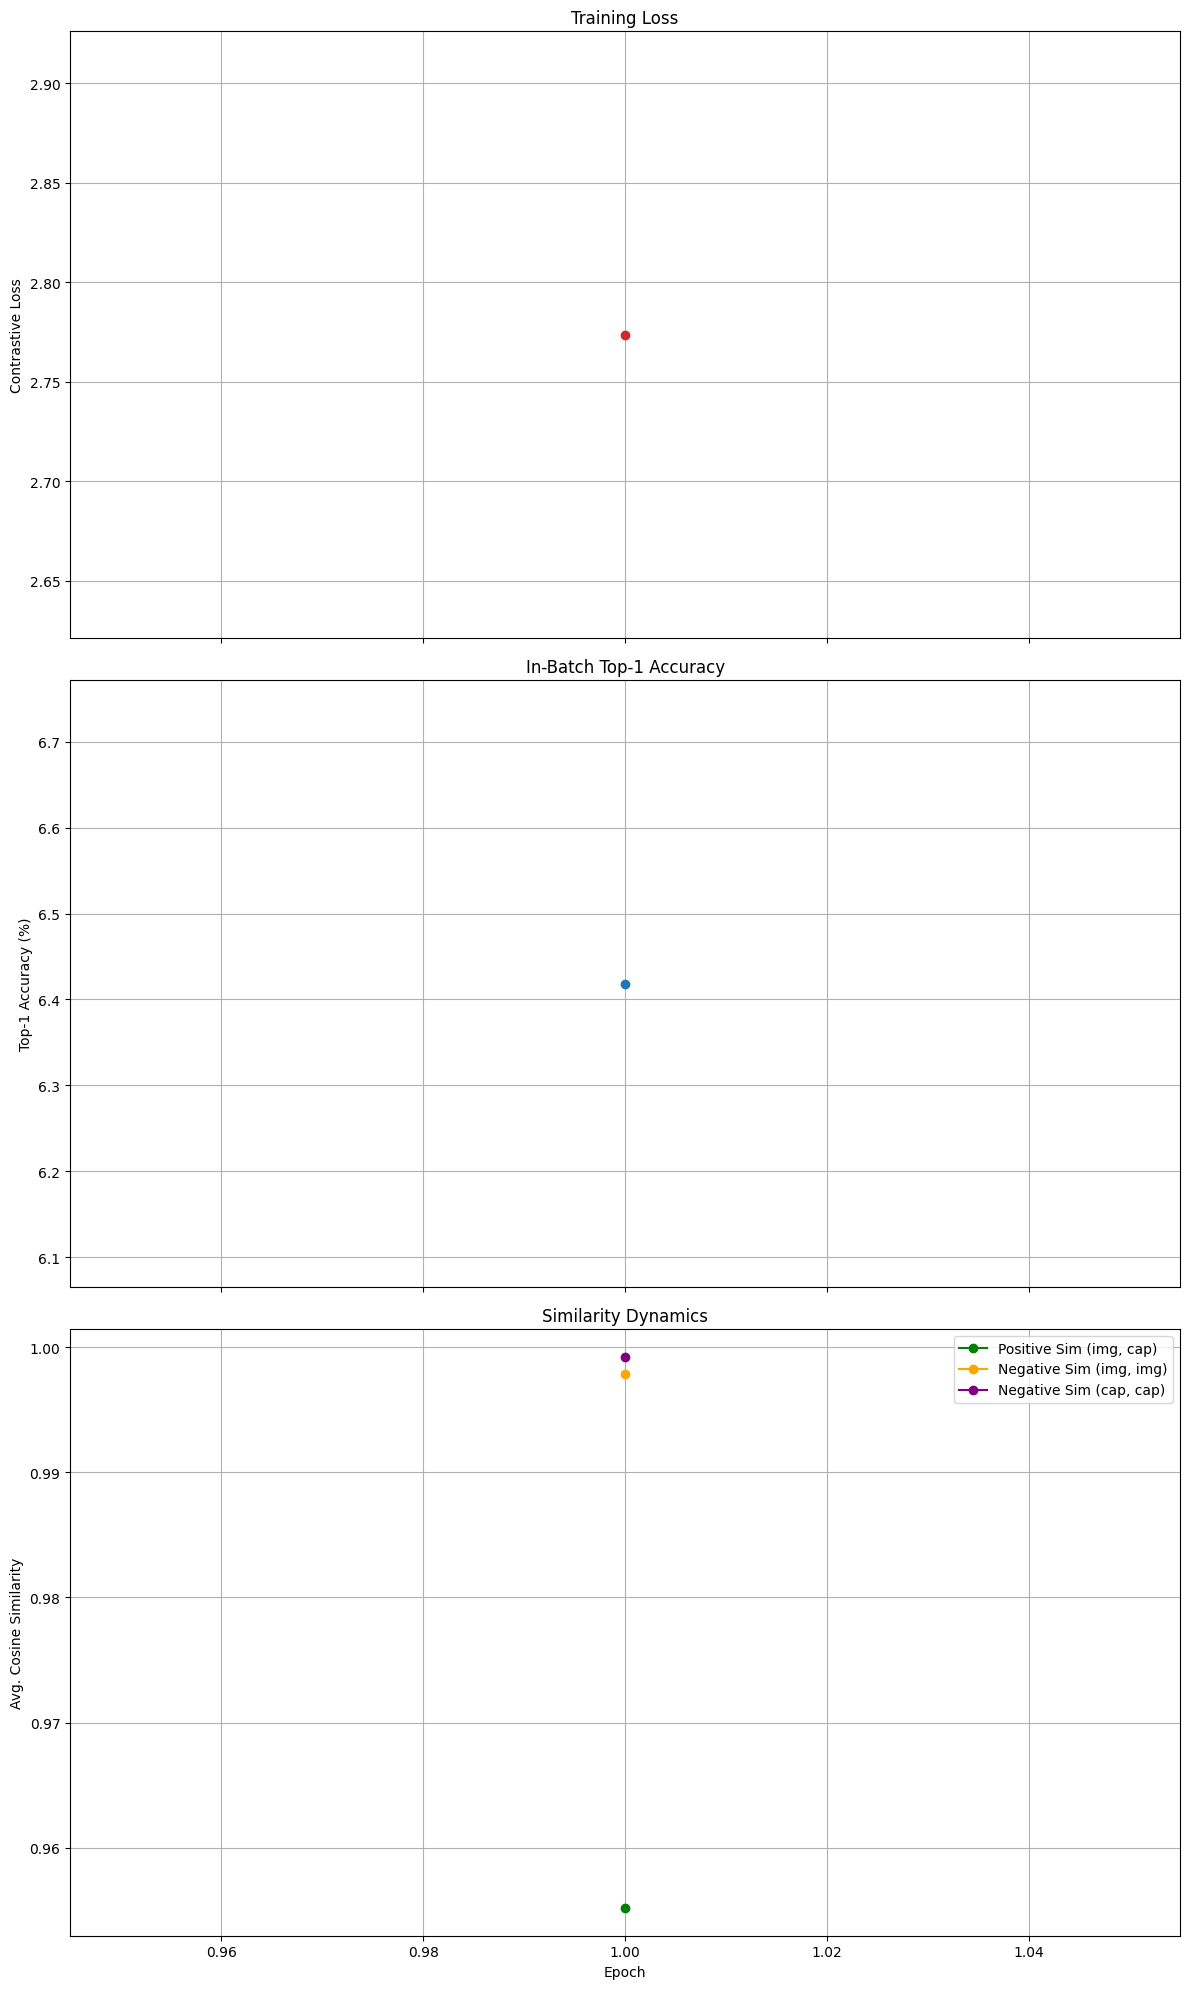

: 

In [ ]:
import os, ast, json, math, random, re
from typing import Dict, Any, List, Tuple, Optional
from PIL import Image
import matplotlib.pyplot as plt
import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
# We import from both libraries
from transformers import AutoTokenizer, AutoModel, PegasusForConditionalGeneration, PegasusTokenizer

# =V=======================
# config
# =========================
SEED = 42
EPOCHS = 1
BATCH_SIZE = 16
IMG_SIZE = 800
NUM_WORKERS = 8
MODEL_NAME = "dinov3_vitl16"
DINO_WEIGHTS = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
SAVE_DIR = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/cvpr"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cache file for paraphrases
CACHE_FILE = "paraphrase_cache_top3.json"

# learning rates
BACKBONE_LR = 1e-5
HEAD_LR = 5e-4
WEIGHT_DECAY_BACKBONE = 0.05
WEIGHT_DECAY_HEAD = 1e-4

DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda:1"

# =========================
# paths
# =========================
IMAGE_META_SPECS = [
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_val_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pakisthan_val_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/bangladesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/bangladesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_val_metadata.txt"),
]

# =========================
# PART 1: PARAPHRASE CACHE GENERATION (Runs only if needed)
# =========================
def get_paraphrases(sentence, model, tokenizer, device, num_return_sequences=10):
    """Generates multiple paraphrases for a base sentence."""
    batch = tokenizer(
        [sentence], truncation=True, padding='longest', max_length=60, return_tensors="pt"
    ).to(device)
    
    translated = model.generate(
        **batch,
        max_length=60,
        num_beams=10,
        num_return_sequences=num_return_sequences,
        temperature=1.5
    )
    
    tgt_text = tokenizer.batch_decode(translated, skip_special_tokens=True)
    return tgt_text

def generate_paraphrase_cache(global_meta_map: Dict[str, Dict[str, Any]], cache_save_path: str):
    """
    Reads the *merged* global metadata map, finds unique TOP 3 landcover combinations,
    and generates paraphrases for each.
    """
    
    # --- 1. Setup Pegasus Model ---
    model_name = 'tuner007/pegasus_paraphrase'
    print(f"Loading Pegasus model {model_name} onto {DEVICE} for cache generation...")
    para_tokenizer = PegasusTokenizer.from_pretrained(model_name)
    para_model = PegasusForConditionalGeneration.from_pretrained(model_name).to(DEVICE)
    print("Pegasus model loaded.")

    print("Finding unique landcover combinations from all metadata files...")
    unique_combinations = set()
    
    # --- First pass: Find all unique TOP 3 combinations ---
    for metadata in global_meta_map.values():
        landcover = metadata.get('landcover_distribution', {})
        if not landcover: continue

        top_covers = sorted(landcover.items(), key=lambda item: item[1], reverse=True)
        
        cover_1 = top_covers[0][0] if len(top_covers) >= 1 else "None"
        cover_2 = top_covers[1][0] if len(top_covers) >= 2 else "None"
        cover_3 = top_covers[2][0] if len(top_covers) >= 3 else "None"
        
        key = f"{cover_1}_{cover_2}_{cover_3}"
        
        if cover_1 != "None":
            unique_combinations.add((key, cover_1, cover_2, cover_3))

    print(f"Found {len(unique_combinations)} unique landcover combinations across all files.")

    # --- Second pass: Generate paraphrases for each unique combo ---
    paraphrase_cache = {}
    
    for key, cover_1, cover_2, cover_3 in tqdm.tqdm(unique_combinations, desc="Generating Paraphrases"):
        
        # Create a dynamic, informative base sentence
        if cover_3 != "None":
            base_sentence = f"A satellite image showing a mix of {cover_1}, {cover_2}, and {cover_3}."
        elif cover_2 != "None":
            base_sentence = f"A satellite image showing a mix of {cover_1} and {cover_2}."
        else: # Only cover_1 exists
            base_sentence = f"A satellite image of an area that is mostly {cover_1}."

        try:
            paraphrases = get_paraphrases(base_sentence, para_model, para_tokenizer, DEVICE, num_return_sequences=10)
            paraphrases.append(base_sentence)
            paraphrase_cache[key] = list(set(paraphrases)) # Use set to ensure unique
        except Exception as e:
            print(f"Failed to generate for {key}: {e}")
            
    # Save the cache to file
    with open(cache_save_path, 'w') as f:
        json.dump(paraphrase_cache, f, indent=2)

    print(f"\n--- Successfully generated and saved top-3 cache to {cache_save_path} ---")
    
    # Free Pegasus model from memory
    del para_model
    del para_tokenizer
    torch.cuda.empty_cache()

# =========================
# PART 2: METADATA LOADING
# =========================
def _parse_meta(meta_str: str) -> Optional[Dict[str, Any]]:
    try:
        return ast.literal_eval(meta_str)
    except Exception:
        pass
    try:
        meta_jsonish = re.sub(r"(?<!\\)'", '"', meta_str)
        return json.loads(meta_jsonish)
    except Exception:
        return None

def load_meta_tsv(path: str) -> Dict[str, Dict[str, Any]]:
    mp = {}
    bad = 0
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                bad += 1
                continue
            
            if "\t" in line:
                parts = line.split("\t", 1)
            else:
                parts = line.split(None, 1) 
            
            if len(parts) != 2:
                bad += 1
                continue
            
            fname, meta_str = parts
            
            meta = _parse_meta(meta_str)
            if isinstance(meta, dict):
                mp[fname] = meta
            else:
                bad += 1
    if bad:
        print(f"Skipped malformed lines: {bad}")
    return mp

def merge_meta_maps(specs: List[Tuple[str,str]]) -> Tuple[List[Tuple[str,str]], Dict[str,Dict[str,Any]]]:
    pairs = []
    global_meta = {}
    print("Merging metadata from all specified files...")
    for img_dir, meta_path in specs:
        if not os.path.isdir(img_dir) or not os.path.isfile(meta_path):
            print(f"Warning: Skipping invalid path pair: {img_dir} or {meta_path}")
            continue
        meta_map = load_meta_tsv(meta_path)
        print(f"Loaded {len(meta_map)} entries from {meta_path}")
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if fname in meta_map:
                pairs.append((img_dir, fname))
                global_meta[fname] = meta_map[fname]
    print(f"Total merged pairs for training/validation: {len(pairs)}")
    return pairs, global_meta

# =========================
# PART 3: DATASET (Using Paraphrase Cache)
# =========================
IMAGENET_MEAN = [0.430, 0.411, 0.296]
IMAGENET_STD  = [0.213, 0.156, 0.143]

class ParaphrasedMetadataDataset(Dataset):
    """
    This dataset reads the pre-computed TOP-3 paraphrase cache for maximum speed.
    It takes the merged 'pairs' and 'meta_map' from merge_meta_maps.
    """
    def __init__(self, 
                 pairs: List[Tuple[str,str]], 
                 meta_map: Dict[str,Dict[str,Any]], 
                 cache_file: str, 
                 size=IMG_SIZE):
        
        self.pairs = pairs
        self.meta_map = meta_map
        self.tf = T.Compose([
            T.Resize(size),
            T.CenterCrop(size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        # 1. Load the pre-computed paraphrases
        print(f"Loading paraphrase cache from {cache_file}...")
        try:
            with open(cache_file, 'r') as f:
                self.paraphrase_cache = json.load(f)
            print("Paraphrase cache loaded.")
        except FileNotFoundError:
            print(f"CRITICAL ERROR: Cache file {cache_file} not found.")
            print("Please run the cache generation step first.")
            raise

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_dir, fname = self.pairs[idx]
        path = os.path.join(img_dir, fname)
        
        # 1. Load Image
        image = Image.open(path).convert('RGB')
        image = self.tf(image)
        
        # 2. Get text description *from the cache*
        metadata = self.meta_map[fname]
        text = self.get_cached_paraphrase(metadata)
        
        # Return in the dict format expected by the training loop
        return {"image": image, "caption": text, "fname": fname}

    def get_cached_paraphrase(self, metadata):
        landcover = metadata.get('landcover_distribution', {})
        if not landcover:
            return "A satellite image of unknown landcover."

        top_covers = sorted(landcover.items(), key=lambda item: item[1], reverse=True)
        
        # Create the same key as used in the generation script
        cover_1 = top_covers[0][0] if len(top_covers) >= 1 else "None"
        cover_2 = top_covers[1][0] if len(top_covers) >= 2 else "None"
        cover_3 = top_covers[2][0] if len(top_covers) >= 3 else "None"
        
        key = f"{cover_1}_{cover_2}_{cover_3}"

        # Look up the list of paraphrases
        phrases_list = self.paraphrase_cache.get(key)
        
        if not phrases_list:
            # Fallback in case the key wasn't found (e.g., "None_None_None")
            return "A satellite image of landcover."

        # Pick one diverse phrase at random
        return random.choice(phrases_list)

def build_loader(pairs, meta_map, cache_file, batch_size=BATCH_SIZE, size=IMG_SIZE, num_workers=NUM_WORKERS):
    ds = ParaphrasedMetadataDataset(pairs, meta_map, cache_file, size=size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    return loader

# =========================
# PART 4: ENCODERS, LOSS, ETC. (Unchanged)
# =========================

def get_dino_cls(model, images: torch.Tensor) -> torch.Tensor:
    out = model.get_intermediate_layers(images, n=1, return_class_token=True)
    cls = out[-1][1]
    return cls

class DINOImageEncoder(nn.Module):
    def __init__(self, model, proj_dim=512, feat_dim=1024):
        super().__init__()
        self.backbone = model
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, images):
        cls = get_dino_cls(self.backbone, images)
        z = self.head(cls)
        return F.normalize(z, dim=-1)

class HFTextEncoder(nn.Module):
    def __init__(self, name="roberta-base", proj_dim=512, out_dim=768):
        super().__init__()
        print(f"Initializing text encoder with {name}")
        self.tok = AutoTokenizer.from_pretrained(name)
        self.lm  = AutoModel.from_pretrained(name)
        self.proj = nn.Linear(out_dim, proj_dim)

    @torch.no_grad()
    def tokenize(self, texts: List[str], max_len=64, device="cpu"):
        enc = self.tok(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        return {k: v.to(device) for k, v in enc.items()}

    def forward(self, input_ids, attention_mask):
        out = self.lm(input_ids=input_ids, attention_mask=attention_mask)
        last = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        z = self.proj(pooled)
        return F.normalize(z, dim=-1)

class ClipLoss(nn.Module):
    def __init__(self, init_logit_scale=math.log(1/0.07)):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.tensor(init_logit_scale))

    def forward(self, z_img, z_txt):
        scale = self.logit_scale.exp().clamp(max=100)
        logits_i2t = scale * (z_img @ z_txt.t())
        logits_t2i = logits_i2t.t()
        targets = torch.arange(z_img.size(0), device=z_img.device)
        li2t = F.cross_entropy(logits_i2t, targets)
        lt2i = F.cross_entropy(logits_t2i, targets)
        return 0.5 * (li2t + lt2i), logits_i2t

class RSCLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder):
        super().__init__()
        self.image_enc = image_encoder
        self.text_enc  = text_encoder
        self.criterion = ClipLoss()

    def forward(self, images, input_ids, attention_mask):
        zi = self.image_enc(images)
        zt = self.text_enc(input_ids, attention_mask)
        loss, logits = self.criterion(zi, zt)
        return loss, logits, zi, zt

def load_dino_vitl16(weights_path: str):
    model = torch.hub.load('facebookresearch/dinov3:main', MODEL_NAME, pretrained=False)
    print(f"Loading DINOv3 weights from: {weights_path}")
    ckpt = torch.load(weights_path, map_location="cpu")
    state = ckpt.get("state_dict", ckpt.get("model", ckpt))
    new_state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(new_state, strict=False)
    return model

def add_param_group(groups, module, lr, wd):
    decay, no_decay = [], []
    for n, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if n.endswith(".bias") or "norm" in n or "ln" in n or "bias" in n:
            no_decay.append(p)
        else:
            decay.append(p)
    if decay:
        groups.append({"params": decay, "lr": lr, "weight_decay": wd})
    if no_decay:
        groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})

def build_optimizer(model, dino_backbone, txt_enc):
    groups = []
    add_param_group(groups, model.image_enc.head, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, txt_enc, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, model.criterion, HEAD_LR, 0.0)
    for p in dino_backbone.parameters():
        p.requires_grad = True
    add_param_group(groups, dino_backbone, BACKBONE_LR, WEIGHT_DECAY_BACKBONE)
    opt = torch.optim.AdamW(groups)
    return opt

# =========================
# PART 5: TRAINING & PLOTTING (With Cache Check)
# =========================
def set_seed(s):
    random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def plot_metrics(save_dir, epochs, epoch_losses, epoch_accs, 
                 epoch_pos_sims, epoch_img_neg_sims, epoch_txt_neg_sims):
    """Saves a 3-panel plot of all training metrics."""
    print("Generating training metrics plot...")
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 20), sharex=True)
    
    epochs_range = range(1, epochs + 1)

    # Plot 1: Loss
    ax1.plot(epochs_range, epoch_losses, marker="o", color="tab:red")
    ax1.set_ylabel("Contrastive Loss")
    ax1.set_title("Training Loss")
    ax1.grid(True)

    # Plot 2: Top-1 Accuracy
    ax2.plot(epochs_range, [acc * 100 for acc in epoch_accs], marker="o", color="tab:blue")
    ax2.set_ylabel("Top-1 Accuracy (%)")
    ax2.set_title("In-Batch Top-1 Accuracy")
    ax2.grid(True)

    # Plot 3: Similarity Comparison
    ax3.plot(epochs_range, epoch_pos_sims, marker="o", color="green", label="Positive Sim (img, cap)")
    ax3.plot(epochs_range, epoch_img_neg_sims, marker="o", color="orange", label="Negative Sim (img, img)")
    ax3.plot(epochs_range, epoch_txt_neg_sims, marker="o", color="purple", label="Negative Sim (cap, cap)")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Avg. Cosine Similarity")
    ax3.set_title("Similarity Dynamics")
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()
    plot_path = os.path.join(save_dir, "training_metrics.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"saved metrics plot to {plot_path}")

def train():
    set_seed(SEED)

    # --- THIS IS THE NEW LOGIC ---
    # 1. Merge all metadata *first*
    pairs, global_meta_map = merge_meta_maps(IMAGE_META_SPECS)
    
    # 2. Check if cache exists. If not, generate it.
    if not os.path.exists(CACHE_FILE):
        print(f"Cache file {CACHE_FILE} not found. Generating it now...")
        # Pass the *merged* metadata map to the cache generator
        generate_paraphrase_cache(global_meta_map, CACHE_FILE)
    else:
        print(f"Found existing cache file: {CACHE_FILE}")

    # 3. Build loader using the cache file and merged metadata
    loader = build_loader(pairs, global_meta_map, CACHE_FILE,
                          BATCH_SIZE, IMG_SIZE, NUM_WORKERS)
    # --- END OF NEW LOGIC ---

    dino = load_dino_vitl16(DINO_WEIGHTS).to(DEVICE)
    img_enc = DINOImageEncoder(dino, proj_dim=512, feat_dim=1024).to(DEVICE)
    
    print("Loading SentenceTransformer model: sentence-transformers/all-mpnet-base-v2")
    txt_enc = HFTextEncoder(name="sentence-transformers/all-mpnet-base-v2", proj_dim=512, out_dim=768).to(DEVICE)

    model = RSCLIP(img_enc, txt_enc).to(DEVICE)

    dino.train()
    img_enc.train()
    txt_enc.train()
    model.train()

    opt = build_optimizer(model, dino, txt_enc)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)

    # Add trackers for all metrics
    epoch_losses = []
    epoch_accs = []
    epoch_pos_sims = []       # Tracks sim(image_A, caption_A)
    epoch_img_neg_sims = []   # Tracks sim(image_A, image_B)
    epoch_txt_neg_sims = []   # Tracks sim(caption_A, caption_B)

    for epoch in tqdm.tqdm(range(EPOCHS), desc="epochs"):
        running_loss = 0.0
        running_acc = 0.0
        running_pos_sim = 0.0
        running_img_neg_sim = 0.0
        running_txt_neg_sim = 0.0

        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            caps   = batch["caption"] # These are now diverse paraphrases
            
            # Tokenize captions
            tok = txt_enc.tokenize(caps, max_len=64, device=DEVICE)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                loss, logits, zi, zt = model(images, tok["input_ids"], tok["attention_mask"])
            
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            with torch.no_grad():
                N = logits.size(0)
                if N < 2: continue 
                ground_truth = torch.arange(N, dtype=torch.long, device=DEVICE)
                
                # Top-1 Accuracy
                preds_i2t = logits.argmax(dim=1)
                acc_i2t = (preds_i2t == ground_truth).float().mean()
                preds_t2i = logits.argmax(dim=0)
                acc_t2i = (preds_t2i == ground_truth).float().mean()
                total_accuracy = (acc_i2t + acc_t2i) / 2.0
                
                # Positive Pair Similarity
                pos_sim = torch.diag(zi @ zt.t()).mean()

                # Image Negative Similarity
                image_sim_matrix = zi @ zi.t()
                off_diag_mask = ~torch.eye(N, dtype=torch.bool, device=DEVICE)
                img_neg_sim = image_sim_matrix[off_diag_mask].mean()
                
                # Text Negative Similarity
                text_sim_matrix = zt @ zt.t()
                txt_neg_sim = text_sim_matrix[off_diag_mask].mean()

            running_loss += loss.item()
            running_acc += total_accuracy.item()
            running_pos_sim += pos_sim.item()
            running_img_neg_sim += img_neg_sim.item()
            running_txt_neg_sim += txt_neg_sim.item()

        loader_len = max(1, len(loader))
        avg_loss = running_loss / loader_len
        avg_acc = running_acc / loader_len
        avg_pos_sim = running_pos_sim / loader_len
        avg_img_neg_sim = running_img_neg_sim / loader_len
        avg_txt_neg_sim = running_txt_neg_sim / loader_len
        
        epoch_losses.append(avg_loss)
        epoch_accs.append(avg_acc)
        epoch_pos_sims.append(avg_pos_sim)
        epoch_img_neg_sims.append(avg_img_neg_sim)
        epoch_txt_neg_sims.append(avg_txt_neg_sim)
        
        print(f"\nEpoch {epoch+1} Results:")
        print(f"  Loss: {avg_loss:.6f}")
        print(f"  Accuracy: {avg_acc*100:.2f}%")
        print(f"  Avg Positive Sim (img-cap): {avg_pos_sim:.4f}")
        print(f"  Avg Negative Sim (img-img): {avg_img_neg_sim:.4f}")
        print(f"  Avg Negative Sim (cap-cap): {avg_txt_neg_sim:.4f}")

        if (epoch + 1) % 5 == 0:
            save_path = os.path.join(SAVE_DIR, f"dino_vitl16_metadata_contrastive_lr_epoch{epoch+1}.pth")
            torch.save(dino.state_dict(), save_path)
            print(f"saved backbone to {save_path}")

    # Call plotting function at the end
    plot_metrics(SAVE_DIR, EPOCHS, epoch_losses, epoch_accs, 
                 epoch_pos_sims, epoch_img_neg_sims, epoch_txt_neg_sims)

if __name__ == "__main__":
    train()